In [1]:
from cirq_sic import *

## Simple WH-POVM with midcircuit measurement

\begin{align}
P(R_{ij}) &= \frac{1}{d}|\langle \phi |D_{ij}^\dagger |\psi\rangle|^2 = \frac{1}{d}|\langle D_{ij}|\psi, \phi^*\rangle|^2\\
&= \frac{1}{d}\left|\langle i, j|(I \otimes F^\dagger)\left(\sum_q X^{-q} \otimes |q\rangle\langle q|\right)|\psi, \phi^*\rangle \right|\\
&= \frac{1}{d}\left|\langle i, j|(F^\dagger \otimes F^\dagger)\left(\sum_q Z^{-q} \otimes |q\rangle\langle q|\right)(F \otimes I)|\psi, \phi^*\rangle \right|
\end{align}

So we should be able to use midcircuit measurement to deal with the final two QFTs!

In [2]:
d = 4
n = int(np.log2(d))
qubits = get_wh_qubits(d, "simple")
phi = load_sic_fiducial(d)
ket = rand_ket(d)
system_qubits = qubits[:n]
fiducial_qubits = qubits[n:2*n]
prepare_system = ansatz_circuit(ket)
prepare_fiducial = ansatz_circuit(phi)
circ = cirq.Circuit((prepare_system(system_qubits),\
                     msimple_wh_povm(system_qubits, fiducial_qubits, prepare_fiducial=prepare_fiducial)))
print(circ)            

                                                                                                                                     ┌─────────┐               ┌──┐   ┌────────┐
(4, 2): ───Rz(-1.46π)───Ry(0.37π)────Rz(0.9π)──────@─────────────────@─────────────────@─────────────────@───H───@───────────×────────@────────────@───×───────────────S^-1────────H───M('s_0')───
                                                   │                 │                 │                 │       │           │        │            │   │               ║
(4, 3): ───Ry(0.792π)──────────────────────────────X───Ry(0.058π)────X───Rz(-0.539π)───X───Rz(-0.168π)───X───────@^0.5───H───×───@────┼──@─────────┼───×───H────M──────╫──────────────────────────
                                                                                                                                 │    │  │         │            ║      ║
(5, 2): ───Rz(-1.63π)───Ry(0.566π)───Rz(-0.133π)───@─────────────────@─────────────────@───────

In [3]:
N = 1000
simulator = cirq.Simulator()
result = simulator.run(circ, repetitions=N)
keys = [f"s_{i}" for i in range(n)] + [f"a_{i}" for i in range(n)]
hist = result.multi_measurement_histogram(keys=keys)
p = np.array([
    hist.get(tuple(map(int, f"{i:0{2*n}b}")), 0) / N
    for i in range(d**2)
])

In [4]:
p_theory = np.array([abs(phi.conj() @ O.conj().T @ ket)**2 for O in wh_operators(d)["D"].reshape(d**2, d, d)])/d
p_theory

array([0.094, 0.018, 0.104, 0.043, 0.023, 0.045, 0.083, 0.044, 0.118,
       0.038, 0.204, 0.065, 0.007, 0.014, 0.058, 0.041])

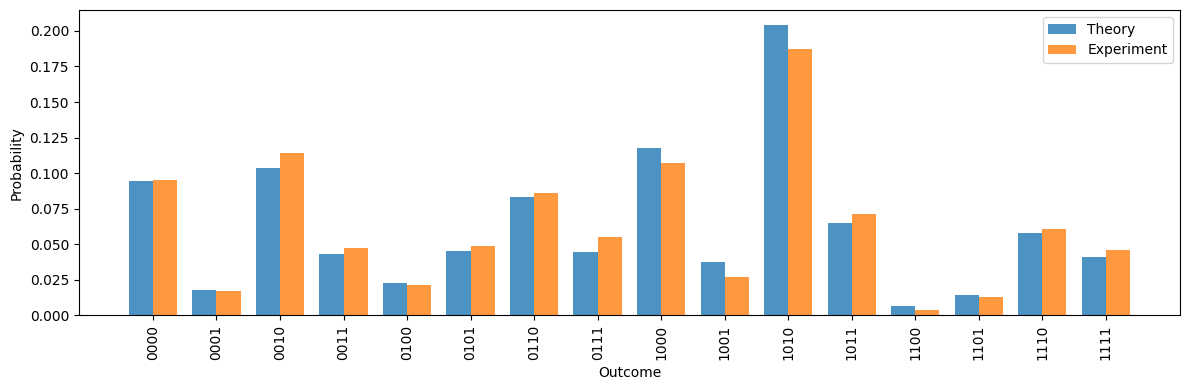

In [5]:
x = np.arange(len(p)) 
width = 0.38
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, p_theory, width=width, label="Theory", alpha=0.8)
plt.bar(x + width/2, p,        width=width, label="Experiment", alpha=0.8)

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks(x, [f"{i:0{2*n}b}" for i in x], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## Let's do it using the cirq_sic system

In [8]:
d = 4
wh_implementation = "msimple"
task = WHPOVMOnStatesTask(dataset_id="test",
                          processor_id="willow_pink",
                          run_type="clean",
                          qubits=get_wh_qubits(d, wh_implementation),
                          n_shots=1000,
                          optimizer="cirq",
                          d=d,
                          fiducial=phi,
                          fiducial_description="numerical_sic",
                          states=[ket],
                          states_description="rand_ket",
                          wh_implementation=wh_implementation)

In [9]:
base_dir = "mtest"
run_sky_ground_task(task, base_dir=base_dir)

2026-05-03 20:50:37 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Starting task...
2026-05-03 20:50:37 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Creating circuits...
2026-05-03 20:50:37 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Optimizing circuits...
2026-05-03 20:50:37 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Sampling...
2026-05-03 20:50:38 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Processing results...
2026-05-03 20:50:38 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Saving...


In [10]:
results = load_results(task, base_dir=base_dir); results

{'timestamp': '2026-05-03T20:50:38.456000',
 'task': WHPOVMOnStatesTask(dataset_id='test', processor_id='willow_pink', run_type='clean', qubits=[cirq.GridQubit(4, 2), cirq.GridQubit(4, 3), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3)], n_shots=1000, optimizer='cirq', d=4, fiducial_description='numerical_sic', states_description='rand_ket', wh_implementation='msimple', fiducial=[(0.15561996860005486-0.46010733746335675j), (-0.16184391789230357+0.366723237896651j), (-0.19058269932469693-0.06445990157021791j), (-0.2338035180008352-0.7129259058214025j)], fiducial_circuit=None, states=[[(-0.08066018696987556+0.17778370069755264j), (0.7917673293275531-0.18168838261332826j), (-0.09062412409612283-0.20403097769216275j), (-0.5021030368377422+0.005646814078944512j)]], states_circuits=None),
 'processed_data': {'r': [[0.099],
   [0.03],
   [0.105],
   [0.037],
   [0.017],
   [0.042],
   [0.082],
   [0.046],
   [0.109],
   [0.046],
   [0.194],
   [0.06],
   [0.011],
   [0.011],
   [0.073],
   [0.038

In [11]:
r = np.array(results["processed_data"]["r"]); r

array([[0.099],
       [0.03 ],
       [0.105],
       [0.037],
       [0.017],
       [0.042],
       [0.082],
       [0.046],
       [0.109],
       [0.046],
       [0.194],
       [0.06 ],
       [0.011],
       [0.011],
       [0.073],
       [0.038]])

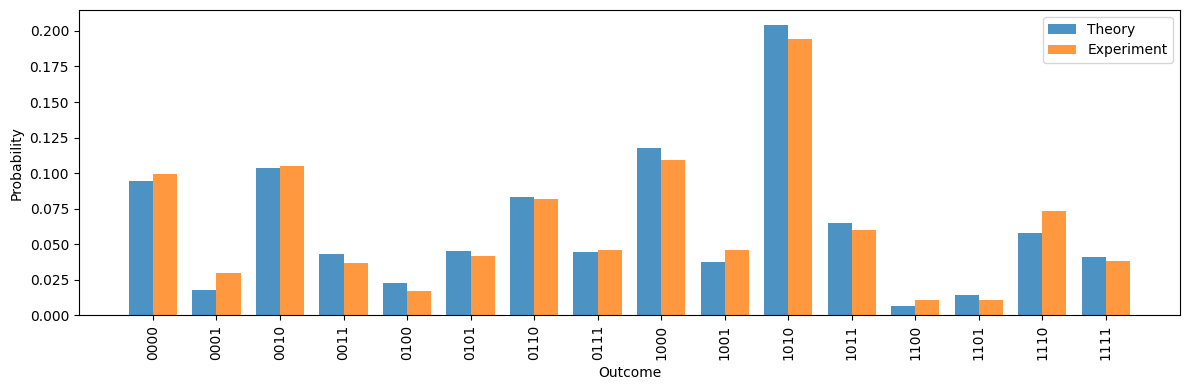

In [ ]:
x = np.arange(len(r)) 
width = 0.38
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, p_theory, width=width, label="Theory", alpha=0.8)
plt.bar(x + width/2, r.flatten(), width=width, label="Experiment", alpha=0.8)

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks(x, [f"{i:0{2*n}b}" for i in x], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## Compare gate counts 

In [16]:
old_task = WHPOVMOnStatesTask(dataset_id="test",
                          processor_id="willow_pink",
                          run_type="clean",
                          qubits=get_wh_qubits(d, "simple"),
                          n_shots=1000,
                          optimizer="cirq",
                          d=d,
                          fiducial=phi,
                          fiducial_description="numerical_sic",
                          states=[ket],
                          states_description="rand_ket",
                          wh_implementation="simple")
run_sky_ground_task(old_task, base_dir=base_dir)

2026-05-03 20:54:41 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Starting task...
2026-05-03 20:54:41 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Creating circuits...
2026-05-03 20:54:41 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Optimizing circuits...
2026-05-03 20:54:42 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Sampling...
2026-05-03 20:54:42 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Processing results...
2026-05-03 20:54:42 [INFO] test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket/cirq_clean_n1k_willow_pink_q4_2-4_3-5_2-5_3: Saving...


In [23]:
print_all_gate_counts("mtest")

mtest/test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket
	cirq_optimized.json (0): [PhasedXPowGate: 31, CZPowGate: 21, ZPowGate: 4, PhasedXZGate: 15, NoneType: 2. Total: 73]
	raw.json (0): [Rz: 8, Ry: 6, CXPowGate: 8, HPowGate: 6, CZPowGate: 5, SwapPowGate: 3, NoneType: 2. Total: 38]
mtest/test/d4/WHPOVMOnStatesTask/simple/numerical_sic/rand_ket
	cirq_optimized.json (0): [PhasedXPowGate: 31, CZPowGate: 21, ZPowGate: 4, PhasedXZGate: 13. Total: 69]
	raw.json (0): [Rz: 8, Ry: 6, CXPowGate: 8, HPowGate: 6, CZPowGate: 7, SwapPowGate: 3. Total: 38]


In [25]:
load_circuits(task, base_dir=base_dir, raw=True)[0]

┌─────────┐               ┌──┐   ┌────────┐
(4, 2): ───Rz(-1.46π)───Ry(0.37π)────Rz(0.9π)──────@─────────────────@─────────────────@─────────────────@───H───@───────────×────────@────────────@───×───────────────S^-1────────H───M('s_0')───
                                                   │                 │                 │                 │       │           │        │            │   │               ║
(4, 3): ───Ry(0.792π)──────────────────────────────X───Ry(0.058π)────X───Rz(-0.539π)───X───Rz(-0.168π)───X───────@^0.5───H───×───@────┼──@─────────┼───×───H────M──────╫──────────────────────────
                                                                                                                                 │    │  │         │            ║      ║
(5, 2): ───Rz(-1.63π)───Ry(0.566π)───Rz(-0.133π)───@─────────────────@─────────────────@─────────────────@───────────────────────@────@^0┼─────────┼───×────────╫──────╫───S^-1────H───M('a_0')───
                                                   │                 │                 │                 │                               │         │   │        ║      ║   ║
(5, 3): ───Ry(0.636π)──────────────────────────────X───Ry(-0.197π)───X───Rz(0.338π)────X───Rz(0.633π)────X───────────────────────────────@^-0.5────@───×───H────╫M─────╫───╫──────────────────────
                                                                                                                                                                ║║     ║   ║
a_1: ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╬@═════╬═══^══════════════════════
                                                                                                                                                                ║      ║
s_1: ═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════@══════^══════════════════════════
                                                                                                                                     └─────────┘               └──┘   └────────┘

In [26]:
load_circuits(old_task, base_dir=base_dir, raw=True)[0]

┌─────────┐
(4, 2): ───Rz(-1.46π)───Ry(0.37π)────Rz(0.9π)──────@─────────────────@─────────────────@─────────────────@───H───@───────────×────────@────────────@───×───────@────────H───M('s_0')──────────────
                                                   │                 │                 │                 │       │           │        │            │   │       │
(4, 3): ───Ry(0.792π)──────────────────────────────X───Ry(0.058π)────X───Rz(-0.539π)───X───Rz(-0.168π)───X───────@^0.5───H───×───@────┼──@─────────┼───×───H───@^-0.5───────M('s_1')──────────────
                                                                                                                                 │    │  │         │
(5, 2): ───Rz(-1.63π)───Ry(0.566π)───Rz(-0.133π)───@─────────────────@─────────────────@─────────────────@───────────────────────@────@^0┼─────────┼───×───────@────────H──────────────M('a_0')───
                                                   │                 │                 │                 │                               │         │   │       │
(5, 3): ───Ry(0.636π)──────────────────────────────X───Ry(-0.197π)───X───Rz(0.338π)────X───Rz(0.633π)────X───────────────────────────────@^-0.5────@───×───H───@^-0.5──────────────────M('a_1')───
                                                                                                                                     └─────────┘